In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
csv_file = r"\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT\20231211_SANTUR\5-Resultados\P1_CONTENEDORES\SPL\peak_clips\P1_CONTENEDORES_peak_clips.csv"
df = pd.read_csv(csv_file)
df

,filename,start_time,end_time,duration,classes,predictions
0,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:09:44,2023-12-11 14:09:47,3.50,"['Vehicle', 'Aircraft']","[0.7409767, 0.25924322]"
1,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:10:34,2023-12-11 14:10:36,2.50,"['Vehicle', 'Aircraft']","[0.7118994, 0.2626036]"
2,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:11:06,2023-12-11 14:11:09,3.50,"['Vehicle', 'Aircraft']","[0.66744727, 0.098212704]"
3,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:28:23,2023-12-11 14:28:25,2.50,"['Vehicle', 'Speech']","[0.3188401, 0.10287674]"
4,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:30:13,2023-12-11 14:30:16,3.50,"['Vehicle', 'Aircraft']","[0.6052738, 0.21368803]"
...,...,...,...,...,...,...
1057,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-19 19:09:16,2023-12-19 19:09:18,2.50,"['Vehicle', 'Skateboard']","[0.2448359, 0.2147274]"
1058,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-19 19:10:43,2023-12-19 19:10:44,1.50,"['Vehicle', 'Rail transport']","[0.3115298, 0.07417421]"
1059,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-19 19:12:13,2023-12-19 19:12:14,1.50,"['Vehicle', 'Speech']","[0.37131992, 0.19201986]"
1060,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-20 03:50:56,2023-12-20 03:51:11,15.50,"['Vehicle', 'Bicycle']","[0.45735258, 0.08593124]"


In [5]:
#preprocessing
csv_file_pre = r"\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT\20231211_SANTUR\5-Resultados\P1_CONTENEDORES\SPL\Peaks\peaks_detection_P1_CONTENEDORES.csv"
df_pre = pd.read_csv(csv_file_pre)
df_pre

,filename,start_time,end_time,duration,leq,LA_values
0,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:09:44,2023-12-11 14:09:47,3,86.53,"[84.61, 86.26, 87.36, 87.34]"
1,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:10:34,2023-12-11 14:10:36,2,89.51,"[85.63, 90.34, 90.92]"
2,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:11:06,2023-12-11 14:11:09,3,89.89,"[86.52, 88.7, 91.55, 91.09]"
3,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:17:53,2023-12-11 14:20:44,3,90.26,"[84.96, 88.11, 92.83, 91.35]"
4,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:24:22,2023-12-11 14:26:30,3,84.92,"[81.8, 85.81, 84.41, 86.38]"
...,...,...,...,...,...,...
1677,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-20 03:50:56,2023-12-20 03:51:11,1,82.59,"[80.87, 83.82]"
1678,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-20 04:02:32,2023-12-20 04:04:19,2,81.49,"[80.18, 81.23, 82.7]"
1679,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-20 04:48:14,2023-12-20 05:02:37,2,80.88,"[78.92, 81.97, 81.2]"
1680,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-20 05:03:52,2023-12-20 05:04:22,2,80.04,"[79.26, 80.25, 80.52]"


In [6]:
# merge dataframes
df = pd.merge(df, df_pre, on='start_time', how='left')
df

,filename_x,start_time,end_time_x,duration_x,classes,predictions,filename_y,end_time_y,duration_y,leq,LA_values
0,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:09:44,2023-12-11 14:09:47,3.50,"['Vehicle', 'Aircraft']","[0.7409767, 0.25924322]",\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:09:47,3,86.53,"[84.61, 86.26, 87.36, 87.34]"
1,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:10:34,2023-12-11 14:10:36,2.50,"['Vehicle', 'Aircraft']","[0.7118994, 0.2626036]",\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:10:36,2,89.51,"[85.63, 90.34, 90.92]"
2,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:11:06,2023-12-11 14:11:09,3.50,"['Vehicle', 'Aircraft']","[0.66744727, 0.098212704]",\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:11:09,3,89.89,"[86.52, 88.7, 91.55, 91.09]"
3,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:28:23,2023-12-11 14:28:25,2.50,"['Vehicle', 'Speech']","[0.3188401, 0.10287674]",\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:28:25,2,84.95,"[81.94, 85.29, 86.47]"
4,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:30:13,2023-12-11 14:30:16,3.50,"['Vehicle', 'Aircraft']","[0.6052738, 0.21368803]",\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:30:16,3,84.19,"[81.75, 84.54, 84.31, 85.4]"
...,...,...,...,...,...,...,...,...,...,...,...
1071,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-19 19:09:16,2023-12-19 19:09:18,2.50,"['Vehicle', 'Skateboard']","[0.2448359, 0.2147274]",\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-19 19:09:18,2,86.79,"[82.13, 89.05, 86.67]"
1072,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-19 19:10:43,2023-12-19 19:10:44,1.50,"['Vehicle', 'Rail transport']","[0.3115298, 0.07417421]",\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-19 19:10:44,1,81.39,"[80.54, 82.1]"
1073,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-19 19:12:13,2023-12-19 19:12:14,1.50,"['Vehicle', 'Speech']","[0.37131992, 0.19201986]",\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-19 19:12:14,1,81.04,"[79.62, 82.11]"
1074,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-20 03:50:56,2023-12-20 03:51:11,15.50,"['Vehicle', 'Bicycle']","[0.45735258, 0.08593124]",\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-20 03:51:11,1,82.59,"[80.87, 83.82]"


In [8]:
# remove columns+
df = df.drop(columns=['filename_y','end_time_y', 'duration_y'])
df

,filename_x,start_time,end_time_x,duration_x,classes,predictions,leq,LA_values
0,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:09:44,2023-12-11 14:09:47,3.50,"['Vehicle', 'Aircraft']","[0.7409767, 0.25924322]",86.53,"[84.61, 86.26, 87.36, 87.34]"
1,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:10:34,2023-12-11 14:10:36,2.50,"['Vehicle', 'Aircraft']","[0.7118994, 0.2626036]",89.51,"[85.63, 90.34, 90.92]"
2,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:11:06,2023-12-11 14:11:09,3.50,"['Vehicle', 'Aircraft']","[0.66744727, 0.098212704]",89.89,"[86.52, 88.7, 91.55, 91.09]"
3,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:28:23,2023-12-11 14:28:25,2.50,"['Vehicle', 'Speech']","[0.3188401, 0.10287674]",84.95,"[81.94, 85.29, 86.47]"
4,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:30:13,2023-12-11 14:30:16,3.50,"['Vehicle', 'Aircraft']","[0.6052738, 0.21368803]",84.19,"[81.75, 84.54, 84.31, 85.4]"
...,...,...,...,...,...,...,...,...
1071,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-19 19:09:16,2023-12-19 19:09:18,2.50,"['Vehicle', 'Skateboard']","[0.2448359, 0.2147274]",86.79,"[82.13, 89.05, 86.67]"
1072,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-19 19:10:43,2023-12-19 19:10:44,1.50,"['Vehicle', 'Rail transport']","[0.3115298, 0.07417421]",81.39,"[80.54, 82.1]"
1073,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-19 19:12:13,2023-12-19 19:12:14,1.50,"['Vehicle', 'Speech']","[0.37131992, 0.19201986]",81.04,"[79.62, 82.11]"
1074,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-20 03:50:56,2023-12-20 03:51:11,15.50,"['Vehicle', 'Bicycle']","[0.45735258, 0.08593124]",82.59,"[80.87, 83.82]"


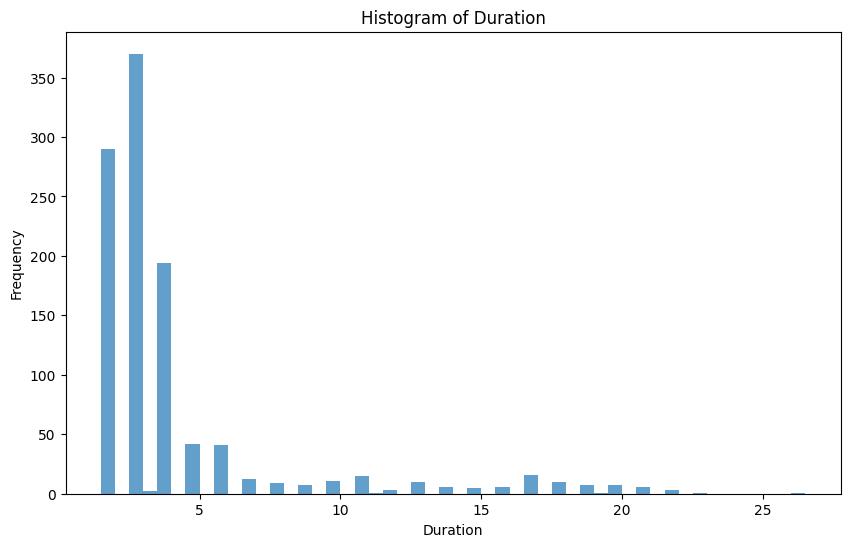

In [7]:
#plot de histogram with the sd for duration column
figure = plt.figure(figsize=(10, 6))
df['duration_x'].plot(kind='hist', bins=50, alpha=0.7)
plt.title('Histogram of Duration')
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.show()